# National allocation of international shipping CO₂

A two-vessel replication of **Selin et al. (2021)**, *Mitigation of CO₂ emissions from
international shipping through national allocation* (Environ. Res. Lett. **16**, 045009),
built entirely from public data.

This notebook walks through `docs/METHODOLOGY.md` section by section, §0 to §8. It
**demonstrates** the pipeline; it does not reimplement it. Every computation calls into
`src/emissions_allocation/`, and every physical formula is cited to its source inline.

## How to read the numbers

Two of the parameters this model needs — **installed power** and **design speed** — cannot
be observed from any free source. Selin et al. used IHS World Register of Shipping, a paid
commercial register. The IMO's own fallback regressions are mutually circular. So three
estimates are carried **in parallel with no primary**, and the spread between them is a
reported result rather than an error to be resolved.

Anything derived rather than observed is marked **[estimated]**. A reader should never be
unsure which is which.

## Scope, honestly

Two vessels demonstrate the *machinery* of national allocation. They cannot reproduce the
paper's *findings*, which are distributional — top-20 rankings, concentration shares, the
OECD split. Those need the full fleet.

What two vessels **can** show is the paper's equity argument in miniature, and they do:
COSCO ITALY's four allocation options collapse onto one national budget, while RCC AMERICA's
land on three. Allocation choice is immaterial for the co-located majority and decisive for
open-registry ships.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from emissions_allocation import Database, load_config
from emissions_allocation import activity, allocation, baselines, impacts, specs, validate

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

cfg = load_config()
INTERIM = cfg.path("interim")
vessel = next(iter(cfg))

print(f"study period   {cfg.start_date} to {cfg.end_date} ({cfg.elapsed_hours:,} hours)")
print(f"vessels        {[v.imo for v in cfg]}")
print(f"scenarios      {len(cfg.scenarios())}")

study period   2017-01-01 to 2024-12-31 (70,128 hours)
vessels        ['9516454', '9277802']
scenarios      16


---
# §0 — Select vessels

**What this step does.** Chooses the study vessels by reproducible criteria rather than by
hand, so a researcher extending this work applies the same filter to any number of ships.

**Inputs** — GFW 4Wings presence at world extent, filtered by flag and vessel type.
**Outputs** — `config/pilot.yaml`, with the criteria values that justified each selection.

Candidate discovery cannot use the ship-name filter, because names are what we are searching
*for*. It uses `flag` and `vessel_type` instead — the other two presence filters that bind.

### Both vessels selected

`selection.py` runs §0.2 steps 1–4 against the live API. Discovery pooled **15,417 distinct
IMOs** across eight sample days and six open registries, narrowed to those with a distinct
name present in every year and a Europe rotation, then pulled port-call data for the
shortlist.

**Step 5 cannot be automated.** Criterion 7 — registered-owner country ≠ flag country, the
whole point of vessel B — requires Equasis, which needs a logged-in account and publishes no
API. That step was closed by hand.

No IMO number anywhere in this project is recalled or invented; every candidate came from a
live presence query.

In [2]:
for v in cfg:
    print(f"IMO {v.imo}  ({v.label})  names={list(v.shipnames)}")
    print(f"  former identities outside the study period: "
          f"{list(v.former_shipnames_outside_period) or 'none'}")

print("\nAllocation keys, both Hong Kong treatments:")
for treatment in cfg.run["hk_treatments"]:
    summary = allocation.summarise_options(cfg, treatment)
    for row in summary.itertuples():
        keys = "  ".join(f"{o}={getattr(row, o)}" for o in allocation.ALLOCATION_OPTIONS)
        verdict = "DEGENERATE" if row.is_degenerate else f"{row.n_distinct_countries} budgets"
        print(f"  {treatment:18s} {keys}   -> {verdict}")

IMO 9516454  (A)  names=['COSCO ITALY']
  former identities outside the study period: ['NE116']
IMO 9277802  (B)  names=['RCC AMERICA', 'HOEGH AMERICA']
  former identities outside the study period: none

Allocation keys, both Hong Kong treatments:
  separate           flag=BHS  owner=IMN  manager=GRC  operator=IMN   -> 3 budgets
  separate           flag=HKG  owner=CHN  manager=CHN  operator=CHN   -> 2 budgets
  folded_into_china  flag=BHS  owner=IMN  manager=GRC  operator=IMN   -> 3 budgets
  folded_into_china  flag=HKG  owner=CHN  manager=CHN  operator=CHN   -> DEGENERATE


---
# §1 — Obtain ship activity data

**What this step does.** Produces a continuous, ordered, hourly position-and-speed series
across the study period, plus the sequence of port calls that defines the vessel's voyages.

**Inputs** — GFW 4Wings presence (`public-global-presence`), GFW Events
(`public-global-port-visits-events`), GFW Vessels identity.
**Outputs** — `vessel_hour`, `port_call`, `voyage_leg`.

### §1.5 Derived speed over ground

Great-circle distance between consecutive hourly positions, over elapsed time:

$$a = \sin^2\!\left(\tfrac{\Delta\varphi}{2}\right) + \cos\varphi_1\cos\varphi_2\,
      \sin^2\!\left(\tfrac{\Delta\lambda}{2}\right)$$
$$d = 2R\arcsin\sqrt{a}, \qquad R = 6371.0088\ \text{km}$$
$$SOG_i = \frac{d}{1.852\,\Delta t}\quad[\text{knots}]$$

*Source: haversine formula; R is the IUGG mean Earth radius. `docs/METHODOLOGY.md` §1.5.*

`SOG` is the IMO's term, but note the provenance differs: in the Fourth GHG Study it is
*transmitted* by the vessel, whereas here it is *derived* from consecutive cell centroids.
§1.6 exists because of that difference.

### §1.6 Smoothing — not cosmetic

GFW credits each vessel-hour to a single 0.01° cell. A ship crossing ~22 cells per hour
lands unpredictably within them, so consecutive-centroid speeds oscillate. Because
propulsion power scales as $v^3$, the error **does not average out**:

$$\overline{SOG}_i = \frac{1}{w}\sum_{k=-(w-1)/2}^{+(w-1)/2} SOG_{i+k}$$

*Source: `docs/METHODOLOGY.md` §1.6. The window $w$ is a sensitivity axis, not a fixed choice.*

In [3]:
spine = pd.read_parquet(INTERIM / f"vessel_hour_{vessel.imo}.parquet")
port_calls = pd.read_parquet(INTERIM / f"port_call_{vessel.imo}.parquet")
legs = pd.read_parquet(INTERIM / f"voyage_leg_{vessel.imo}.parquet")

print(f"vessel_hour  {len(spine):,} rows")
print(f"port_call    {len(port_calls):,} rows, confidence {sorted(set(port_calls.confidence))}, "
      f"{port_calls.port_iso3.nunique()} countries")
print(f"voyage_leg   {len(legs):,} rows, {int(legs.is_eu_eu.sum())} EU->EU, "
      f"{int(legs.is_international.sum())} international")
port_calls.port_iso3.value_counts().head(8).to_frame("port calls").T

vessel_hour  70,128 rows
port_call    389 rows, confidence ['4'], 17 countries
voyage_leg   388 rows, 27 EU->EU, 225 international


port_iso3,CHN,TWN,USA,VNM,EGY,KOR,DEU,MYS
port calls,194,46,39,22,18,16,10,10


### Chart 1 — the oscillation smoothing corrects

Raw derived speed against the smoothed series, over a week of open-ocean cruising. The raw
trace swings wildly while the vessel is in fact holding a steady speed; that swing is
cell-centroid quantisation, not the ship.

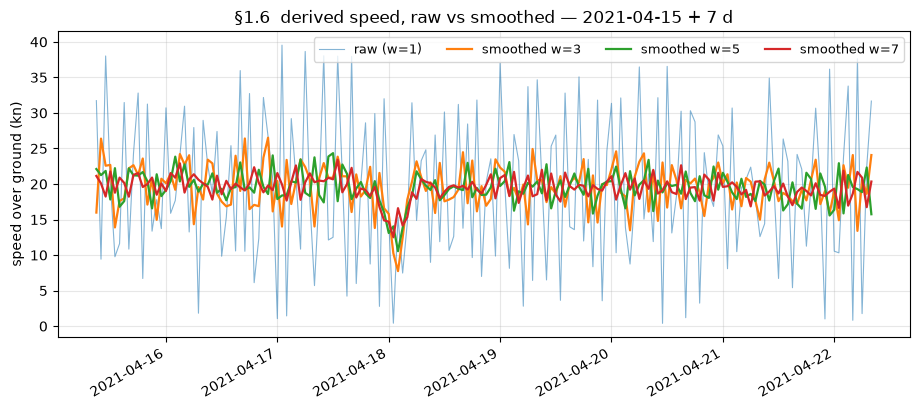

The v^3 bias the smoothing exists to reduce:
 window  mean(v^3)/(mean v)^3
      1              1.942910
      3              1.380464
      5              1.383254
      7              1.414544


In [4]:
window_days = 7
at_sea = spine[(~spine.is_inactive) & (spine.sog_raw > 8)]
start = at_sea.ts.iloc[len(at_sea) // 2]
sample = spine[(spine.ts >= start) & (spine.ts < start + pd.Timedelta(days=window_days))]

fig, ax = plt.subplots()
ax.plot(sample.ts, sample.sog_raw, lw=0.8, alpha=0.55, label="raw (w=1)")
for w in [w for w in cfg.run["smoothing_windows"] if w > 1]:
    ax.plot(sample.ts, sample[f"sog_w{w}"], lw=1.6, label=f"smoothed w={w}")
ax.set_ylabel("speed over ground (kn)")
ax.set_title(f"§1.6  derived speed, raw vs smoothed — {start:%Y-%m-%d} + {window_days} d")
ax.legend(ncol=4, fontsize=9)
fig.autofmt_xdate()
plt.show()

active = spine[~spine.is_inactive]
bias = pd.DataFrame({
    "window": cfg.run["smoothing_windows"],
    "mean(v^3)/(mean v)^3": [activity.cubic_bias(active[f"sog_w{w}"])
                             for w in cfg.run["smoothing_windows"]],
})
print("The v^3 bias the smoothing exists to reduce:")
print(bias.to_string(index=False))

### §1.7 Coverage — and a finding the specification did not anticipate

`docs/METHODOLOGY.md` §1.7 and §4.5 treat the coverage correction as negligible, on the
strength of 2024 alone (99.98%). Measured across the full period it is not.

More importantly, the gaps are **two different phenomena** and they need opposite treatment:

* **Scattered short gaps** are thin AIS reception. The vessel was trading and hours were
  missed, so $E/\text{coverage}$ correctly recovers them.
* **Contiguous absences** are the hull out of service. Zero presence hours *and* zero port
  calls, from two independent endpoints. Scaling those up would fabricate voyages.

Applied uniformly, the §4.5 correction would multiply 2019 by 2.77× **for a ship that was
laid up for 282 days**. So `coverage_active` — observed over *in-service* hours — is what
the correction divides by.

In [5]:
coverage = activity.coverage_by_year(spine)
display(coverage.style.format({
    "coverage_raw": "{:.2%}", "coverage_active": "{:.2%}",
}).set_caption("§1.7 coverage: raw counts a lay-up as missing data; active does not"))

gaps = activity.find_gaps(spine, min_hours=cfg.run["inactivity_gap_days"] * 24)
print("Out-of-service windows (no presence AND no port calls):")
for g in gaps.itertuples():
    print(f"  {g.start_ts:%Y-%m-%d} -> {g.end_ts:%Y-%m-%d}   "
          f"{int(g.hours):,} h ({int(g.hours)//24} d)")

,imo,year,elapsed_hours,inactive_hours,active_hours,observed_hours,interpolated_hours,coverage_raw,coverage_active
0,9516454,2017,8760,0,8760,7185,1575,82.02%,82.02%
1,9516454,2018,8760,1708,7052,6233,819,71.15%,88.39%
2,9516454,2019,8760,4906,3854,3159,695,36.06%,81.97%
3,9516454,2020,8784,1866,6918,6388,530,72.72%,92.34%
4,9516454,2021,8760,0,8760,8163,597,93.18%,93.18%
5,9516454,2022,8760,0,8760,8498,262,97.01%,97.01%
6,9516454,2023,8760,0,8760,8743,17,99.81%,99.81%
7,9516454,2024,8784,0,8784,8782,2,99.98%,99.98%


Out-of-service windows (no presence AND no port calls):
  2019-06-10 -> 2020-03-18   6,772 h (282 d)
  2018-05-19 -> 2018-07-29   1,708 h (71 d)


---
# §2 — Ship specifications and parameters

**What this step does.** Assembles the technical parameters the emission model needs, and is
explicit that two of them cannot be observed from any free source.

**Inputs** — Equasis, public vessel registers, published regressions.
**Outputs** — `config/vessel_specs.yaml`, every estimated field carrying `value`, `source`
and `method`.

### §2.1 TEU capacity

IMO Table 17 indexes container ships by TEU; Equasis does not carry it. Invert the beam
relation:

$$B = 3.27\,\mathrm{TEU}^{0.29} \quad\Longrightarrow\quad
  \mathrm{TEU} = \left(\frac{B}{3.27}\right)^{1/0.29}$$

*Source: Cepowski & Chorab (2021), Ocean Engineering 238, 109727 — beam relation, fitted on
215 container designs built 2015–2020.*

Beam is the better proxy for container ships because it sets the on-deck row count.

### §2.2 Design speed and installed power — three estimates

**Estimate A — IMO EEXI curve fit**

$$V = A\cdot \mathrm{DWT}^{B}, \qquad P_{ME} = C\cdot \mathrm{DWT}^{D}$$

*Source: IMO Resolution MEPC.333(76) (2021), Table 1. Containership: A=3.240, B=0.183,
C=0.504, D=1.030.* The resolution writes $P_{ME}$ for **installed** power; this project calls
it `MCR` throughout, because the Fourth GHG Study uses that symbol for instantaneous demand.

**Estimate B — Admiralty coefficient, calibrated**

$$Fn = \frac{v}{\sqrt{g\,L_{BP}}} \quad\Longrightarrow\quad
  V = \frac{Fn\sqrt{g\,L_{BP}}}{0.5144}\ [\text{kn}]$$
$$\mathrm{MCR} = \frac{\Delta^{2/3}\,V^{3}}{C_{adm}}$$

*Sources: Froude number, standard naval architecture. $C_{adm}$ calibrated on Charchalis
(2014), Journal of KONES 21(2), Table 1 — 17 container ships with matched speed, power and
displacement: median 482.*

Displacement by two routes, which bracket a real convention difference:

$$\Delta = C_B\,L_{BP}\,B\,T\,\rho \qquad\text{and}\qquad \Delta = \mathrm{DWT}/0.80$$

**Estimate C — sourced specification.** Open item 4. Not found; raises rather than guessing.

In [6]:
teu = specs.resolve_teu(vessel, cfg)
print(f"TEU inverted from beam {vessel.require_spec('beam_m')} m: {teu:,.0f}  [estimated]")

print("\nCepowski & Chorab DWT relations against the observed hull (why we trust the inversion):")
val = pd.DataFrame(specs.validate_hull_relations(vessel, cfg.defaults)).T
display(val.style.format("{:.1f}"))

estimates = specs.build_estimates(vessel, cfg)
rows = []
for name, e in estimates.items():
    rows.append({"estimate": e.label, "design speed (kn)": e.design_speed_kn,
                 "MCR (kW)": e.mcr_kw, "within fleet envelope": e.within_fleet_envelope,
                 "estimated": e.estimated})
display(pd.DataFrame(rows).style.format({"design speed (kn)": "{:.2f}", "MCR (kW)": "{:,.0f}"})
        .set_caption("§2.2  three estimates, no primary — the spread IS the result"))

try:
    specs.estimate_c_sourced(vessel, cfg.defaults)
except Exception as exc:
    print(f"\nEstimate C — OPEN ITEM 4:\n  {type(exc).__name__}: {str(exc)[:220]}...")

TEU inverted from beam 51.2 m: 13,174  [estimated]

Cepowski & Chorab DWT relations against the observed hull (why we trust the inversion):


,predicted,observed,error_pct
lbp,344.4,345.0,-0.2
beam,52.8,51.2,3.2
draught,15.8,16.0,-1.4


,estimate,design speed (kn),MCR (kW),within fleet envelope,estimated
0,A (EEXI curve fit),25.55,"67,912",False,True
1,"B (Admiralty, calibrated)",22.62,"78,258",True,True



Estimate C — OPEN ITEM 4:
  MissingParameter: '9516454.power_estimates.C.design_speed_kn' has no value in config. Estimate C is a SOURCED specification (docs/METHODOLOGY.md §2.2, open item 4). Fill in vessel_specs.yaml vessels.<imo>.power_estimates.C from shipbuilde...


### Chart 2 — estimate A falls outside the modern container fleet

`D = 1.030` makes power nearly *linear* in deadweight, which breaks at the top of the
container range where modern designs are deliberately under-powered for slow steaming.

The predicted 28.92 kn exceeds **24.5 kn, the maximum service speed among 215 distinct
container designs built since 2015** (Cepowski & Chorab, Table 1). This is a reported
validation failure, not something corrected — the estimate is carried through to the CO₂
result so a reader can see what an out-of-envelope power assumption does.

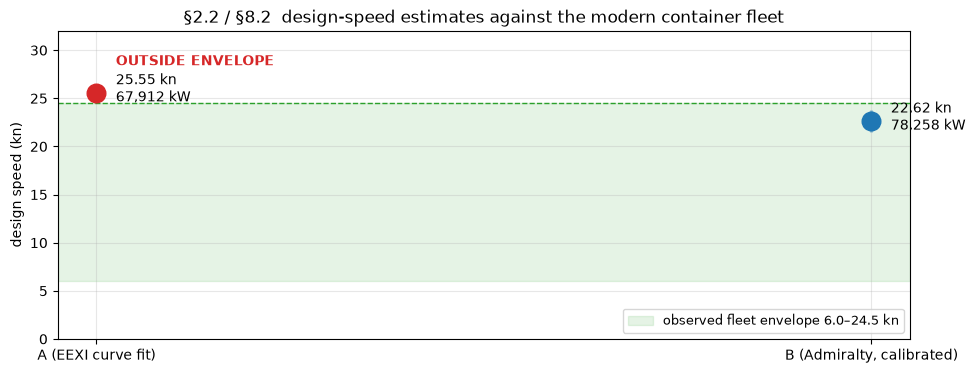

In [7]:
env = cfg.defaults["fleet_speed_envelope"][vessel.require_spec("ship_type")]
fig, ax = plt.subplots(figsize=(11, 4))
ax.axhspan(env["min_kn"], env["max_kn"], color="tab:green", alpha=0.12,
           label=f"observed fleet envelope {env['min_kn']}–{env['max_kn']} kn")
ax.axhline(env["max_kn"], color="tab:green", ls="--", lw=1)

for i, (name, e) in enumerate(estimates.items()):
    ok = e.within_fleet_envelope
    ax.scatter([i], [e.design_speed_kn], s=180, zorder=3,
               color="tab:blue" if ok else "tab:red")
    ax.annotate(f"{e.design_speed_kn:.2f} kn\n{e.mcr_kw:,.0f} kW",
                (i, e.design_speed_kn), textcoords="offset points", xytext=(14, -6))
    if not ok:
        ax.annotate("OUTSIDE ENVELOPE", (i, e.design_speed_kn),
                    textcoords="offset points", xytext=(14, 20), color="tab:red",
                    fontweight="bold")

if "B" in estimates:
    lo, hi = estimates["B"].variants["speed_kn_range"]
    ax.vlines(list(estimates).index("B"), lo, hi, color="tab:blue", lw=2, alpha=0.5)

ax.set_xticks(range(len(estimates)))
ax.set_xticklabels([estimates[k].label for k in estimates])
ax.set_ylabel("design speed (kn)")
ax.set_ylim(0, 32)
ax.set_title("§2.2 / §8.2  design-speed estimates against the modern container fleet")
ax.legend(loc="lower right", fontsize=9)
plt.show()

---
# §3 — Fuel type and emission factors

**What this step does.** Assigns a fuel to every vessel-hour and attaches the corresponding
emission factor and specific fuel consumption.

**Inputs** — IMO Fourth GHG Study Tables 19 and 21; Marine Regions ECA polygons (MARPOL
Annex VI Reg. 14); `voyage_leg` from §1.
**Outputs** — `fuel_assignment` at vessel-hour grain.

### §3.1 Assignment rule

A vessel-hour burns **distillate** (MDO/MGO) when *any* of the following holds, and
**residual** (HFO) otherwise:

1. the main engine is high-speed — not applicable here (SSD);
2. the position falls inside an ECA polygon — point-in-polygon;
3. the hour belongs to a voyage leg between two EU ports.

*Source: Selin et al. (2021), following the IMO Fourth GHG Study.*

Condition 3 is read from an actual port-call sequence, which is a genuine improvement on the
EEZ proxy that gridded-only data would have forced.

### §3.2 The IMO 2020 sulphur cap is immaterial to CO₂

The study period straddles the 0.50% global sulphur cap of 1 January 2020. For CO₂ this
changes nothing: the Fourth GHG Study assigns low-sulphur HFO the **same carbon content and
emission factor** as HFO (Table 21, LSHFO 1.0% → 3.114). Scrubber fitting affects SOx only.
There is deliberately no fuel-switch date branch anywhere in the code.

*Source: IMO Fourth GHG Study 2020, Table 21 (printed p.74).*

In [8]:
fuel_assign = pd.read_parquet(INTERIM / f"fuel_assignment_{vessel.imo}.parquet")
total = len(fuel_assign)
print(f"{total:,} vessel-hours")
print(f"  inside an ECA:    {int(fuel_assign.in_eca.sum()):,} "
      f"({fuel_assign.in_eca.mean():.1%})")
print(f"  on an EU->EU leg: {int(fuel_assign.is_eu_eu_leg.sum()):,} "
      f"({fuel_assign.is_eu_eu_leg.mean():.1%})")

ef = cfg.factors["emission_factors"]["fuels"]
split = (fuel_assign.fuel_type.value_counts().rename("hours").to_frame()
         .assign(share=lambda d: d.hours / total,
                 ef_f=lambda d: [ef[f]["ef_f"] for f in d.index]))
display(split.style.format({"hours": "{:,}", "share": "{:.1%}"})
        .set_caption("§3.3  fuel split and Table 21 emission factors (g CO2 / g fuel)"))

print("\nECA hours by area (corroborates the port-call pattern independently):")
print(fuel_assign[fuel_assign.in_eca].eca_area.value_counts().to_string())

70,128 vessel-hours
  inside an ECA:    4,310 (6.1%)
  on an EU->EU leg: 1,532 (2.2%)


,hours,share,ef_f
fuel_type,,,
HFO,"64,841",92.5%,3.114000
MDO,"5,287",7.5%,3.206000



ECA hours by area (corroborates the port-call pattern independently):
eca_area
North American area 1    3061
North Sea area           1147
Baltic Sea area           102


---
# §4 — Calculate CO₂ emissions

**What this step does.** Converts the hourly activity series into CO₂ mass per hour, summed
to ship-year, for every scenario.

**Inputs** — `vessel_hour`, `vessel_specs`, `fuel_assignment`, IMO Tables 16, 17, 19, 21.
**Outputs** — `emissions_hour`, `emissions_year`, both scenario-keyed.

### §4.2 Main-engine power demand

$$Load_i = \left(\frac{\overline{SOG}_i}{V}\right)^{3}\!\!,\ \text{capped at }1.0
\qquad \dot W_{ME,i} = \mathrm{MCR}\cdot Load_i$$

*Source: `docs/METHODOLOGY.md` §4.2; the cubic law is standard propulsion theory.*

with $\dot W_{ME,i}=0$ below 7% MCR and in the At berth / Anchored modes.
*Source: IMO Fourth GHG Study 2020, printed p.70 — "At engine loads below 7%, fuel
consumption and all the emissions derived from the main engine are assumed to be zero."*

### §4.4 Load-corrected specific fuel consumption — IMO equation (10), verbatim

$$SFC_{ME,i} = SFC_{base}\cdot\underbrace{\left(0.455\,Load_i^{2} - 0.710\,Load_i + 1.280\right)}_{CF_L}$$

*Source: IMO Fourth GHG Study 2020, equation (10), printed p.71.*

The quadratic minimises at $Load = 0.710/(2\times0.455) = 0.78$, matching the study's stated
~80% MCR optimum — an internal check that the coefficients are transcribed correctly, and one
the test suite asserts.

Auxiliary engines and boilers are **not** corrected — IMO equation (11):

$$FC_{AE|BO,i} = SFC_{base}\cdot \dot W_{AE|BO,i}$$

### §4.5 Hourly and annual CO₂

$$FC_i = \left[\dot W_{ME,i}SFC_{ME,i} + \dot W_{AE,i}SFC_{base,AE}
        + \dot W_{BO,i}SFC_{base,BO}\right]\Delta t \quad[\text{g fuel}]$$
$$E_{CO_2,i} = FC_i\cdot EF_f / 10^{6}\quad[\text{t}], \qquad
  E_{ship,y} = \sum_i E_{CO_2,i}$$

*Source: IMO Fourth GHG Study 2020 §2.2; emission factors from Table 21.*

$LLF$ does not appear: CO₂'s low-load factor is 1.00 at every load (Table 20), because CO₂
varies directly with fuel consumption, which is already load-dependent.

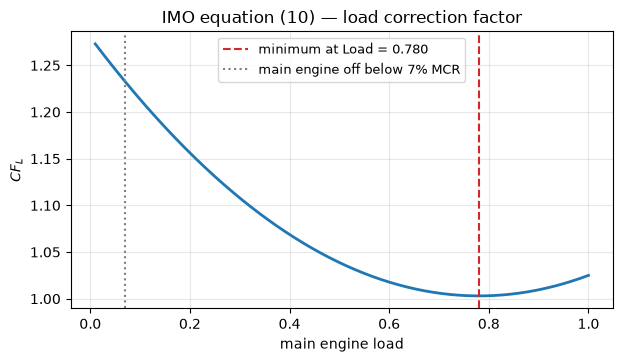

analytic minimum -b/2a = 0.7802   (the study states ~80% MCR)


In [9]:
c = cfg.factors["load_correction"]
loads = np.linspace(0.01, 1.0, 400)
cf_l = c["a"] * loads**2 + c["b"] * loads + c["c"]

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(loads, cf_l, lw=2)
ax.axvline(c["minimises_at"], color="tab:red", ls="--",
           label=f"minimum at Load = {c['minimises_at']:.3f}")
ax.axvline(c["main_engine_cutoff_load"], color="tab:grey", ls=":",
           label=f"main engine off below {c['main_engine_cutoff_load']:.0%} MCR")
ax.set_xlabel("main engine load"); ax.set_ylabel("$CF_L$")
ax.set_title("IMO equation (10) — load correction factor")
ax.legend(fontsize=9)
plt.show()

print(f"analytic minimum -b/2a = {-c['b'] / (2 * c['a']):.4f}"
      f"   (the study states ~80% MCR)")

### §4.1 Operating mode — IMO Table 16, and one documented departure

Table 16 assigns one of five phases from speed, main-engine load, distance to port and
distance to coast. The five columns are an **ordered ladder**; the first applicable wins.

*Source: IMO Fourth GHG Study 2020, Table 16, printed p.66.*

Two things about this table are worth stating, because both differ from
`docs/METHODOLOGY.md` §4.1:

**The 'Port 1–5 nm' column is tanker-only.** The source footnotes it: *"Applicable to
chemical tankers, liquified gas tankers, oil tankers and other liquids tankers only"* —
liquid tankers are lightered offshore and so can berth within 5 nm of port. The methodology
document reproduces the column without that restriction, which would let a container ship
count as At berth up to 5 nm out. **The source is followed here.**

**At berth is determined from port-visit intervals, not distance.** The source separates
berth from anchor by distance because it had no better signal, and §4.1 flags the exposure.
We have a better one: a GFW port-visit event asserts, from a different endpoint and with a
confidence score, that the vessel was in port between two timestamps. Using distance to
anchorage coordinates instead put only 1,143 h at berth against 17,427 h actually in port.
`run.use_port_visit_intervals: false` restores strict Table 16 for comparison.

In [10]:
hourly = pd.read_parquet(INTERIM / f"emissions_hour_{vessel.imo}.parquet")
yearly = pd.read_parquet(INTERIM / f"emissions_year_{vessel.imo}.parquet")

ref = hourly[hourly.scenario_id == f"{cfg.run['power_estimates'][0]}_w3"]
mode_split = (ref.operating_mode.value_counts().rename("hours").to_frame()
              .assign(share=lambda d: d.hours / len(ref)))
display(mode_split.style.format({"hours": "{:,}", "share": "{:.1%}"})
        .set_caption("§4.1  operating-mode split (estimate A, w=3)"))

t17 = cfg.factors["auxiliary_boiler_power"]
band = next(b for b in t17["ship_types"]["container"]["bands"] if b["min"] == 12000)
display(pd.DataFrame({"mode": t17["modes"], "boiler kW": band["boiler"],
                      "auxiliary kW": band["auxiliary"]})
        .set_index("mode").T.style.set_caption(
            "§4.3  IMO Table 17 — container 12,000–14,499 TEU"))

,hours,share
operating_mode,,
slow_transit,"40,079",65.0%
at_berth,"14,900",24.2%
normal_cruising,"3,514",5.7%
anchored,"2,474",4.0%
manoeuvring,681,1.1%


mode,at_berth,anchored,manoeuvring,sea
boiler kW,630,630,630,0
auxiliary kW,1300,1800,3250,2050


### Chart 3 — the track, coloured by operating mode

Each point is one vessel-hour at its 0.01° cell centroid. Berth and anchorage hours cluster
tightly at ports; transit hours trace the trade lanes.

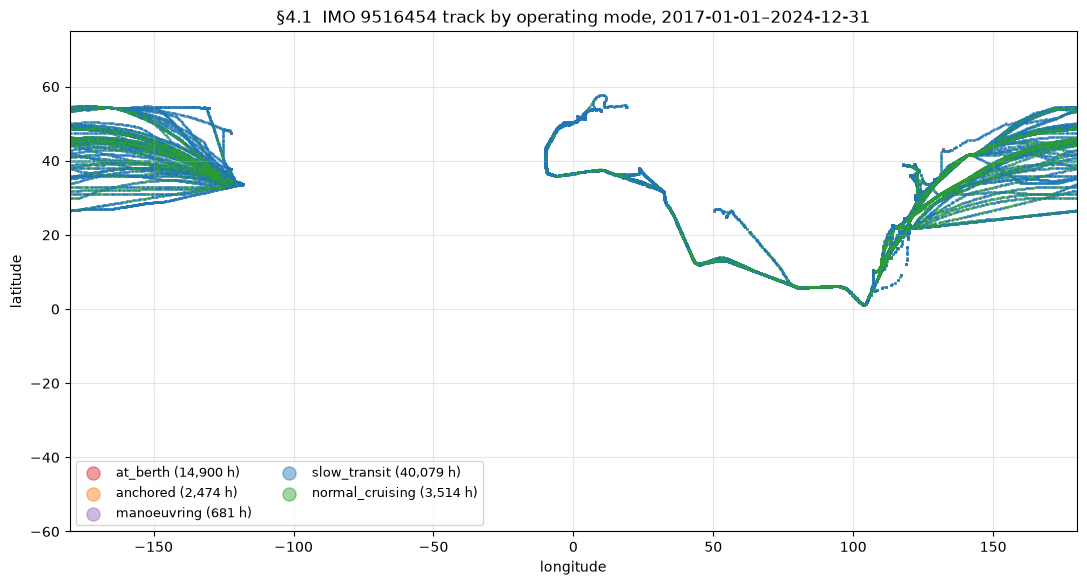

In [11]:
track = ref.merge(spine[["imo", "ts", "lat", "lon"]], on=["imo", "ts"], how="left").dropna(
    subset=["lat", "lon"])
colours = {"at_berth": "tab:red", "anchored": "tab:orange", "manoeuvring": "tab:purple",
           "slow_transit": "tab:blue", "normal_cruising": "tab:green"}

fig, ax = plt.subplots(figsize=(13, 6.5))
for mode, colour in colours.items():
    sub = track[track.operating_mode == mode]
    if not sub.empty:
        ax.scatter(sub.lon, sub.lat, s=1.4, alpha=0.45, c=colour,
                   label=f"{mode} ({len(sub):,} h)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_xlim(-180, 180); ax.set_ylim(-60, 75)
ax.set_title(f"§4.1  IMO {vessel.imo} track by operating mode, "
             f"{cfg.start_date}–{cfg.end_date}")
ax.legend(markerscale=8, fontsize=9, loc="lower left", ncol=2)
plt.show()

### Chart 4 — annual CO₂ under each power estimate

The gap between the two series is the §2.2 spread propagating into the result. It is an
uncertainty band, not an error: no free source supplies installed power, so there is no basis
for preferring either.

Years flagged low-confidence had thin AIS reception, and 2018 and 2019 also contain the
out-of-service windows found in §1.7.

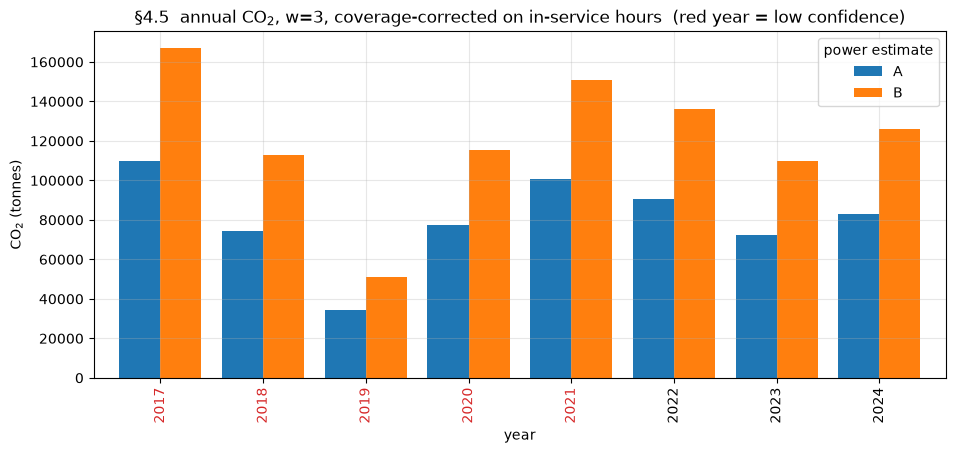

power_estimate,A,B
year,,
2017,"109,768","167,140"
2018,"74,338","112,820"
2019,"34,307","51,199"
2020,"77,374","115,377"
2021,"100,757","150,753"
2022,"90,597","136,159"
2023,"72,340","109,572"
2024,"83,202","126,061"


8-year total, w=3:
  estimate A:      642,683 t
  estimate B:      969,081 t
  spread: 1.51x


In [12]:
w = 3
sub = yearly[yearly.smoothing_window == w]
pivot = sub.pivot_table(index="year", columns="power_estimate", values="co2_tonnes")
low_years = sorted(sub[sub.is_low_confidence].year.unique())

fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax, width=0.8)
for i, yr in enumerate(pivot.index):
    if yr in low_years:
        ax.get_xticklabels()[i].set_color("tab:red")
ax.set_ylabel("CO$_2$ (tonnes)")
ax.set_title(f"§4.5  annual CO$_2$, w={w}, coverage-corrected on in-service hours"
             "  (red year = low confidence)")
ax.legend(title="power estimate")
plt.show()

display(pivot.style.format("{:,.0f}").set_caption("annual CO2 (t)"))
totals = sub.groupby("power_estimate").co2_tonnes.sum()
print(f"8-year total, w={w}:")
for k, v in totals.items():
    print(f"  estimate {k}: {v:>12,.0f} t")
print(f"  spread: {totals.max() / totals.min():.2f}x")

---
# §5 — Allocate to countries

**What this step does.** Attributes annual CO₂ to countries under each allocation rule.

$$E_{c,\text{option}} = \sum_{\text{ships}} E_{\text{ship}}\cdot
  \mathbb{1}\!\left[\text{key}_{\text{option}}(\text{ship}) = c\right]$$

*Source: Selin et al. (2021) §2.*

**Four of the paper's five options are reproduced.** The fifth — bunker fuel — rests on
national marine-bunker *sales* statistics, and allocating one ship's emissions to a bunkering
country would require knowing where it took fuel, which no public dataset records. It is out
of scope **by construction, not by omission**.

Two caveats on the keys, both from §5.2:

* **Operator is a proxy.** Equasis has no operator field; commercial manager stands in. This
  partially collapses the operator and manager options.
* **Equasis gives an address, not a country of incorporation.** GFW's `registryOwners.flag`
  returns HKG for this Shanghai-registered owner — it appears to echo the ship's flag rather
  than owner domicile, and is **not used**.

---
# §6 — Compare with carbon budgets

$$B_c\,[\text{Mt CO}_2] = B_c\,[\text{Mt C}]\times 3.664$$

*Source: Global Carbon Budget 2025, National Fossil Carbon Emissions v2025, sheet
"Territorial Emissions" (header at row index 11). **The GCB reports million tonnes of
carbon, not CO₂.***

National columns already exclude bunker fuels — only the World total includes them — so the
denominator is clean and adding shipping emissions does not double-count.

### §6.4 The Hong Kong question — resolved against the paper itself

Selin et al.'s supplementary Table 1 carries **199 countries and no Hong Kong row**. No
Taiwan, no Macao either: it is aligned strictly to the UNFCCC party list. **The paper folds
Hong Kong into China**, so `folded_into_china` is the replication-faithful treatment.

Both are still computed, because the two baselines differ by a factor of 369 and that gap is
itself the methodological finding.

In [13]:
base = baselines.build_baselines(cfg)
b2024 = base[base.year == 2024]
rows = []
for t in cfg.run["hk_treatments"]:
    sub = b2024[b2024.hk_treatment == t]
    hk = sub[sub.country == "Hong Kong"].mtco2
    rows.append({"treatment": t,
                 "Hong Kong (Mt CO2)": hk.iloc[0] if len(hk) else np.nan,
                 "China (Mt CO2)": sub[sub.country == "China"].mtco2.iloc[0]})
display(pd.DataFrame(rows).style.format({"Hong Kong (Mt CO2)": "{:,.1f}",
                                         "China (Mt CO2)": "{:,.1f}"}, na_rep="folded in")
        .set_caption("§6.4  2024 national baselines under each treatment"))

check = baselines.shipping_cross_check(cfg, 2024)
print(f"§6.2 cross-check — GCB 'International Shipping' 2024: "
      f"{check['mtc']:.2f} MtC = {check['mtco2']:.0f} Mt CO2")
print("  (an independent global total to sanity-check any fleet-scale result)")

,treatment,Hong Kong (Mt CO2),China (Mt CO2)
0,separate,33.3,"12,289.0"
1,folded_into_china,folded in,"12,322.4"


§6.2 cross-check — GCB 'International Shipping' 2024: 170.15 MtC = 623 Mt CO2
  (an independent global total to sanity-check any fleet-scale result)


---
# §7 — Compute allocation impacts

$$\Delta E_c = E_c, \qquad
  \Delta E\%_c = 100\cdot\frac{\Delta E_c}{B_c}, \qquad
  \text{rank}_c = \mathrm{RANK}()\ \text{over}\ (\text{option},\text{scenario})$$

*Source: Selin et al. (2021) §3.*

**Ranking and concentration shares are structurally meaningless at n = 1** — with one country
per option the top-20 share is always 1.0. The code path exists and is exercised because the
fleet-scale version needs it, and it is labelled rather than interpreted.

### Chart 5 — the allocation comparison

This is the headline methodological result. **Identical emissions, two territory
conventions**: the same tonnage is a ~370× larger share of Hong Kong's budget than of
China's. Nothing the ship did changes; only the convention does.

**Two vessels, opposite behaviour under the same rules.** This is the paper's equity
finding reproduced at n = 2:

* **COSCO ITALY** — a Hong Kong flag with all three commercial roles in China. Under the
  paper's own territory alignment all four options land on **one** national budget. The
  choice of allocation rule is *immaterial* for this hull.
* **RCC AMERICA** — a Bahamas flag, an Isle of Man owner and operator, a Greek manager.
  The four options land on **three** budgets. The choice of rule is *decisive*.

Neither is exceptional. Selin et al. find 74% of ships have owner, operator and manager
in one country, covering 61% of emissions — the co-located majority COSCO ITALY belongs
to. The ships the rule moves are systematically those on open registries, and RCC AMERICA
is one of them.

Allocation keys side by side -- the qualitative result at n = 2:


option,imo,flag,manager,operator,owner,n_distinct_countries,is_degenerate,hk_treatment
0,9277802,BHS,GRC,IMN,IMN,3,False,separate
1,9516454,HKG,CHN,CHN,CHN,2,False,separate


option,imo,flag,manager,operator,owner,n_distinct_countries,is_degenerate,hk_treatment
0,9277802,BHS,GRC,IMN,IMN,3,False,folded_into_china
1,9516454,HKG,CHN,CHN,CHN,1,True,folded_into_china


,option,country,gcb_name,hk_treatment,power_estimate,delta_e_mt,baseline_mt,delta_e_pct
170,flag,HKG,China,folded_into_china,A,0.0832,"12,322.4",0.000675
171,flag,BHS,Bahamas,folded_into_china,A,0.0203,3.1,0.662009
177,flag,HKG,China,folded_into_china,B,0.1261,"12,322.4",0.001023
182,flag,HKG,Hong Kong,separate,A,0.0832,33.3,0.249678
183,flag,BHS,Bahamas,separate,A,0.0203,3.1,0.662009
189,flag,HKG,Hong Kong,separate,B,0.1261,33.3,0.378289
362,manager,CHN,China,folded_into_china,A,0.0832,"12,322.4",0.000675
363,manager,GRC,Greece,folded_into_china,A,0.0203,53.4,0.038083
369,manager,CHN,China,folded_into_china,B,0.1261,"12,322.4",0.001023
374,manager,CHN,China,separate,A,0.0832,"12,289.0",0.000677


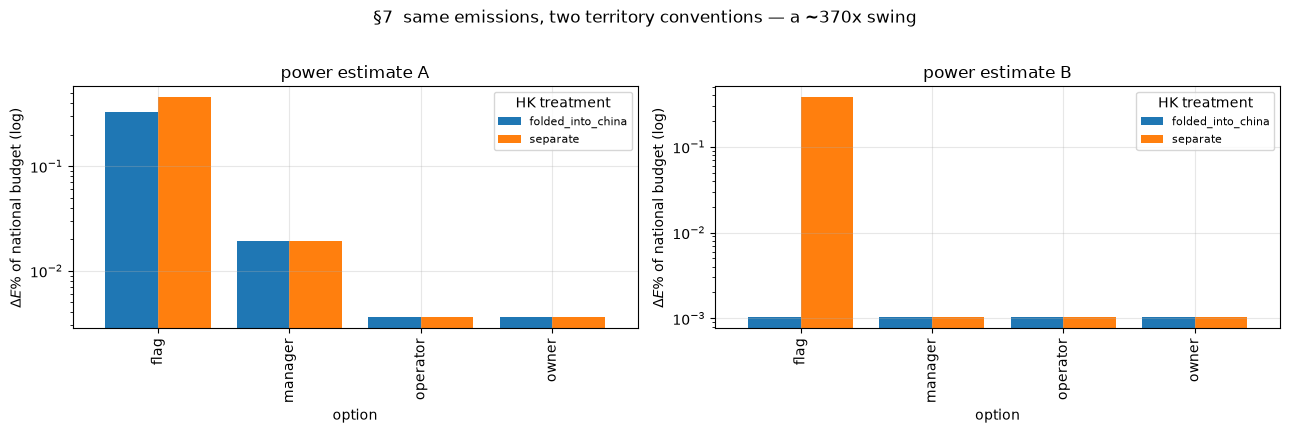

,option,country,hk_treatment,delta_e_mt_min,delta_e_mt_max,spread_ratio
7,flag,BHS,folded_into_china,0.0195,0.0218,1.12x
15,flag,BHS,separate,0.0195,0.0218,1.12x
23,flag,HKG,folded_into_china,0.0796,0.1330,1.67x
31,flag,HKG,separate,0.0796,0.1330,1.67x
39,manager,CHN,folded_into_china,0.0796,0.1330,1.67x
47,manager,CHN,separate,0.0796,0.1330,1.67x
55,manager,GRC,folded_into_china,0.0195,0.0218,1.12x
63,manager,GRC,separate,0.0195,0.0218,1.12x
71,operator,CHN,folded_into_china,0.0796,0.1330,1.67x
79,operator,CHN,separate,0.0796,0.1330,1.67x


In [14]:
im = pd.read_parquet(INTERIM / "impacts.parquet")
view = im[(im.smoothing_window == 3) & (im.year == 2024)]

print("Allocation keys side by side -- the qualitative result at n = 2:")
for treatment in cfg.run["hk_treatments"]:
    summary = allocation.summarise_options(cfg, treatment)
    display(summary.style.set_caption(f"§5.1  allocation keys, HK treatment: {treatment}"))

display(view[["option", "country", "gcb_name", "hk_treatment", "power_estimate",
              "delta_e_mt", "baseline_mt", "delta_e_pct"]]
        .sort_values(["option", "hk_treatment", "power_estimate"])
        .style.format({"delta_e_mt": "{:.4f}", "baseline_mt": "{:,.1f}",
                       "delta_e_pct": "{:.6f}"})
        .set_caption("§7  2024 allocation impacts, w=3"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, est in zip(axes, sorted(view.power_estimate.unique())):
    d = view[view.power_estimate == est]
    p = d.pivot_table(index="option", columns="hk_treatment", values="delta_e_pct")
    p.plot(kind="bar", ax=ax, logy=True, width=0.8)
    ax.set_title(f"power estimate {est}")
    ax.set_ylabel(r"$\Delta E\%$ of national budget (log)")
    ax.legend(title="HK treatment", fontsize=8)
fig.suptitle("§7  same emissions, two territory conventions — a ~370x swing", y=1.02)
plt.tight_layout(); plt.show()

spread = impacts.scenario_spread(im)
display(spread[spread.year == 2024][["option", "country", "hk_treatment",
                                     "delta_e_mt_min", "delta_e_mt_max", "spread_ratio"]]
        .style.format({"delta_e_mt_min": "{:.4f}", "delta_e_mt_max": "{:.4f}",
                       "spread_ratio": "{:.2f}x"})
        .set_caption("§8.1  scenario spread — the uncertainty band, not an error"))

---
# §8 — Sensitivity and validation

### §8.1 The two dominant drivers

1. **Installed power and design speed** — three estimates, no primary.
2. **Speed-smoothing window** — the $v^3$ bias.

Remaining uncertainties — coverage correction, displacement convention, TEU estimation,
engine-type assignment — are documented qualitatively rather than propagated.

### §8.2 Validation

`THETIS-MRV` is used **only** to validate, never as an input — it is EU-scope and this study
allocates globally. Feeding it back would make the comparison circular and import an EU
boundary into a global allocation.

In [15]:
checks = validate.run_all(cfg, vessel, spine, port_calls, legs,
                          activity.coverage_by_year(spine), hourly, yearly, estimates)
for c in checks:
    print(c.line())
    if c.basis:
        print(f"            basis: {c.basis}")

display(validate.summarise(checks).style.set_caption("§8.2  validation summary"))
print("\nThe fleet-envelope FAIL is the EXPECTED result for estimate A (§2.2).")

[PASS   ] Identity integrity: one IMO throughout: 9516454
            basis: distinct IMO in vessel_hour
[WARN   ] Hour conservation: 8 years, active coverage 82.0%-100.0%; below 95% in 5 year(s): 2017 82.0%, 2018 88.4%, 2019 82.0%, 2020 92.3%, 2021 93.2%
            basis: observed hours / in-service hours
[PASS   ] Leg-speed plausibility: 346 legs with movement, median 13.2 kn, 95th pct 19.3 kn; 5 legs above 30.0 kn are anchorage-segmentation artefacts, not voyages (5/5 same-country, 0 same-port, 1.0 h = 0.00% of leg time)
            basis: great-circle distance / leg duration; impossible legs diagnosed
[PASS   ] Port-call/track agreement: 20,107 h at berth/anchored/manoeuvring against 17,427 h inside port visits (ratio 1.15)
            basis: modes vs event intervals
[FAIL   ] Fleet envelope: A at 25.55 kn outside the published range (inside: B)
            basis: observed service-speed range for the ship type
[PASS   ] Smoothing sensitivity: w=1:1.94x w=3:1.38x w=5:1.38x w=7:1.41

,check,status,detail,basis
0,Identity integrity,PASS,one IMO throughout: 9516454,distinct IMO in vessel_hour
1,Hour conservation,WARN,"8 years, active coverage 82.0%-100.0%; below 95% in 5 year(s): 2017 82.0%, 2018 88.4%, 2019 82.0%, 2020 92.3%, 2021 93.2%",observed hours / in-service hours
2,Leg-speed plausibility,PASS,"346 legs with movement, median 13.2 kn, 95th pct 19.3 kn; 5 legs above 30.0 kn are anchorage-segmentation artefacts, not voyages (5/5 same-country, 0 same-port, 1.0 h = 0.00% of leg time)",great-circle distance / leg duration; impossible legs diagnosed
3,Port-call/track agreement,PASS,"20,107 h at berth/anchored/manoeuvring against 17,427 h inside port visits (ratio 1.15)",modes vs event intervals
4,Fleet envelope,FAIL,A at 25.55 kn outside the published range (inside: B),observed service-speed range for the ship type
5,Smoothing sensitivity,PASS,w=1:1.94x w=3:1.38x w=5:1.38x w=7:1.41x (lowest at w=3),mean(v^3)/(mean v)^3 over in-service hours
6,THETIS-MRV,PASS,"1 year(s) comparable in MRV scope; modelled/verified A=0.64x, B=0.98x (closest: B); at_dock covers 17% of calls",modelled emissions restricted to MRV scope against EMSA-verified figures -- the only external ground truth in this project



The fleet-envelope FAIL is the EXPECTED result for estimate A (§2.2).


---
## What remains open

These are stated rather than worked around. Each is a named error or a PENDING marker in the
code, never a substituted default.

| # | Item | Effect |
|---|---|---|
| 1 | **Vessel B not selected** | Allocation is degenerate at n = 1; §0.2 steps 1–4 are automated, step 5 needs Equasis |
| 2 | ~~Selin supplementary Table 1~~ | **Closed** — 199 countries, no Hong Kong row; the paper folds it into China |
| 3 | ~~Coastline layer~~ | **Closed** — land derived from EEZ_land_union minus EEZ v12 |
| 4 | **Estimate C** | No free source for installed power / design speed; raises on use |
| 5 | Smoothing window | Now measured across the full series, not one day: bias 1.94× → 1.38× at w=3 |
| 6 | Joint-regime EEZs | Default `ISO_SOV1`, affected hours reported separately |
| 7 | THETIS-MRV export | Annual CO₂ remains **UNVERIFIED** against external ground truth |

### Findings that contradict the specification

* **Coverage is not uniform.** §1.7 and §4.5 assume it is negligible from 2024 alone. It runs
  36%–99.98%, and two contiguous lay-ups mean a uniform correction would fabricate voyages.
* **Table 16's Port 1–5 nm column is tanker-only.** §4.1 reproduces it without the footnote.
* **At berth cannot be found from anchorage distance.** Port-visit intervals are used instead.
* **Estimate B's power range is wider than quoted.** §2.2 rounds the Froude speeds to 22–23 kn;
  the full 21.48–23.75 kn range gives 64,788–93,656 kW rather than 69,600–85,100 kW.